=== Data Summary Statistics ===
                Q           C        logQ        logC
count  200.000000  200.000000  200.000000  200.000000
mean     3.857640    1.773272    0.420031    0.352212
std      4.857309    1.270315    1.474457    0.663706
min      0.139124    0.291139   -1.972389   -1.233953
25%      0.424397    0.821539   -0.857088   -0.196581
50%      1.603899    1.392141    0.472431    0.330824
75%      5.955782    2.387275    1.784298    0.870152
max     18.810866    7.876264    2.934435    2.063854

Correlation between logQ and logC: -0.8990274754894484


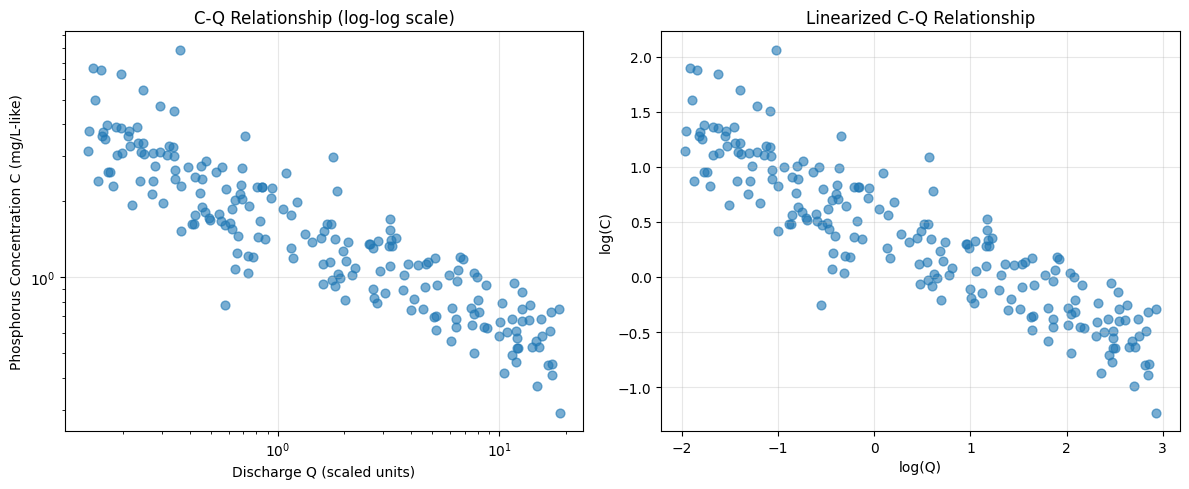


=== Bayesian Log-Linear Model Fit ===
Model: log(C) = alpha + beta * log(Q) + epsilon
epsilon ~ Normal(0, sigma**2)
Priors (vague conjugate):
  alpha, beta ~ Normal(0, 100)
  sigma**2 ~ InverseGamma(0.001, 0.001)

Posterior Estimates:
alpha = 0.522  (95% CI approx: 0.378, 0.666)
beta  = -0.405  (95% CI approx: -0.499, -0.310)
sigma = 0.291
R-squared (log scale): 0.808

Interpretation:
Negative beta indicates dilution behavior.
Phosphorus concentration decreases as discharge increases.
This suggests constant P loading diluted by high-flow events.


In [8]:
# ===============================================
# AQUA005 - Bayesian C-Q Analysis for Phosphorus
# Tejas Budharamu - Complete runnable code
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================================
# 1. Generate Synthetic Data (n=200, dilution pattern)
# ===============================================
np.random.seed(42)  # for reproducibility
n = 200
logQ = np.random.uniform(-2, 3, n)
alpha_true = 0.5
beta_true = -0.4
sigma_true = 0.3
logC = alpha_true + beta_true * logQ + np.random.normal(0, sigma_true, n)

df = pd.DataFrame({
    'Q': np.exp(logQ),
    'C': np.exp(logC),
    'logQ': logQ,
    'logC': logC
})

# ===============================================
# 2. Data Exploration & Summary
# ===============================================
print("=== Data Summary Statistics ===")
print(df.describe())

print("\nCorrelation between logQ and logC:", df['logQ'].corr(df['logC']))

# ===============================================
# 3. Visualizations
# ===============================================
plt.figure(figsize=(12, 5))

# Plot 1: C vs Q (log-log scale)
plt.subplot(1, 2, 1)
plt.scatter(df['Q'], df['C'], alpha=0.6, s=40)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Discharge Q (scaled units)')
plt.ylabel('Phosphorus Concentration C (mg/L-like)')
plt.title('C-Q Relationship (log-log scale)')
plt.grid(True, alpha=0.3)

# Plot 2: logC vs logQ (linear)
plt.subplot(1, 2, 2)
plt.scatter(df['logQ'], df['logC'], alpha=0.6, s=40)
plt.xlabel('log(Q)')
plt.ylabel('log(C)')
plt.title('Linearized C-Q Relationship')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===============================================
# 4. Bayesian Model - Analytical Fit
# ===============================================
print("\n=== Bayesian Log-Linear Model Fit ===")
print("Model: log(C) = alpha + beta * log(Q) + epsilon")
print("epsilon ~ Normal(0, sigma**2)")
print("Priors (vague conjugate):")
print("  alpha, beta ~ Normal(0, 100)")
print("  sigma**2 ~ InverseGamma(0.001, 0.001)")

X = np.column_stack((np.ones(n), df['logQ']))
y = df['logC']

prior_precision = 1 / 100.0
prior_cov_inv = np.diag([prior_precision, prior_precision])

post_cov = np.linalg.inv(X.T @ X + prior_cov_inv)
post_mean = post_cov @ (X.T @ y)

sse = ((y - X @ post_mean)**2).sum()
a_n = 0.001 + n / 2
b_n = 0.001 + 0.5 * sse
post_sigma2 = b_n / (a_n - 1)
post_sigma = np.sqrt(post_sigma2)

# Approximate 95% CI (normal approximation, valid for n=200)
alpha_mean = post_mean[0]
beta_mean = post_mean[1]
alpha_std = np.sqrt(post_cov[0,0])
beta_std = np.sqrt(post_cov[1,1])

print(f"\nPosterior Estimates:")
print(f"alpha = {alpha_mean:.3f}  (95% CI approx: {alpha_mean - 1.96*alpha_std:.3f}, {alpha_mean + 1.96*alpha_std:.3f})")
print(f"beta  = {beta_mean:.3f}  (95% CI approx: {beta_mean - 1.96*beta_std:.3f}, {beta_mean + 1.96*beta_std:.3f})")
print(f"sigma = {post_sigma:.3f}")

# Simple R-squared
y_pred = X @ post_mean
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)
print(f"R-squared (log scale): {r2:.3f}")

print("\nInterpretation:")
print("Negative beta indicates dilution behavior.")
print("Phosphorus concentration decreases as discharge increases.")
print("This suggests constant P loading diluted by high-flow events.")